In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from NNSolver import Net
import Constants as c
import torch
from Problem import Problem
import numpy as np
import pandas as pd
import DataUtil
from TrainingUtil import set_seed
import pickle
import matplotlib.pyplot as plt
from pathlib import Path
import hashlib
import json


Comparing to cvx

In [35]:
K = 4
test_length = 100
compare_seed = 42
cvx_cache_version = 'cvx_v1'

cache_dir = Path('data')
cache_dir.mkdir(exist_ok=True)
compare_input_path = cache_dir / f'compare_to_cvx_inputs_K_{K}_N_{test_length}_seed_{compare_seed}.pkl'
cvx_cache_path = cache_dir / 'compare_to_cvx_cache.pkl'

if compare_input_path.exists():
    with open(compare_input_path, 'rb') as f:
        compare_inputs = pickle.load(f)
    D = compare_inputs['D']
    H = compare_inputs['H']
    print(f'loaded fixed D and H from {compare_input_path}')
else:
    set_seed(compare_seed)
    total_data_bits = K * 4e3
    D = (DataUtil.generate_D_k_distribution(test_length, K) * total_data_bits).numpy()
    H = DataUtil.generate_channel_gains(test_length, K).numpy()
    with open(compare_input_path, 'wb') as f:
        pickle.dump({'D': D, 'H': H}, f)
    print(f'saved fixed D and H to {compare_input_path}')

if cvx_cache_path.exists():
    with open(cvx_cache_path, 'rb') as f:
        cvx_cache = pickle.load(f)
else:
    cvx_cache = {}


def cvx_curve_cache_key(name, values):
    values = np.asarray(values, dtype=float)
    values_hash = hashlib.sha1(values.round(12).tobytes()).hexdigest()[:12]
    return f'{cvx_cache_version}_{name}_K_{K}_N_{test_length}_seed_{compare_seed}_{values_hash}'


def get_cached_cvx_curve(name, values, build_problem):
    cache_key = cvx_curve_cache_key(name, values)

    if cache_key in cvx_cache:
        print(f'loaded cached CVX result: {name}')
        return np.array(cvx_cache[cache_key], dtype=float)

    print(f'running CVX result: {name}')
    t_total_cvx = []
    for i, value in enumerate(values):
        print(f'cvx {name} i = {i}')
        problem = build_problem(value)
        problem.optimize(model='cvx')
        t_total_cvx.append(problem.get_t_total_max())

    cvx_cache[cache_key] = t_total_cvx
    with open(cvx_cache_path, 'wb') as f:
        pickle.dump(cvx_cache, f)

    return np.array(t_total_cvx, dtype=float)


def model_checkpoint_path(problem):
    settings = {
        'K': problem.K,
        'total_bandwidth': float(problem.total_bandwidth),
        'total_compute_speed': float(c.total_compute_power),
        'beta_max': float(problem.beta_max),
        'comp_speed_mean': float(problem.comp_speed.mean()),
        'tr_power_mean': float(problem.tr_power.mean()),
        'train_total_data_bits': float(problem.K * 4e3),
        'architecture': 'Net:v2',
    }
    settings_json = json.dumps(settings, sort_keys=True)
    settings_hash = hashlib.sha1(settings_json.encode('utf-8')).hexdigest()[:10]

    readable_name = (
        f"checkpoint_K_{problem.K}"
        f"_B_{float(problem.total_bandwidth):.3g}"
        f"_beta_{float(problem.beta_max):.3g}"
        f"_p_{float(problem.tr_power.mean()):.3g}"
    )

    return Path('model') / f'{readable_name}_{settings_hash}.pth'


def train_cached_model(problem, force_retrain=False, **train_kwargs):
    checkpoint_path = model_checkpoint_path(problem)
    checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

    if checkpoint_path.exists() and not force_retrain:
        print(f'loading cached model: {checkpoint_path}')
        model = Net(
            problem.K,
            problem.total_bandwidth,
            c.total_compute_power,
            problem.beta_max,
        ).to(problem.device)
        model.load_state_dict(torch.load(checkpoint_path, map_location=problem.device))
        return model

    return problem.train_new_model(
        checkpoint_path=checkpoint_path,
        **train_kwargs,
    )


beta = np.linspace(1, 2.5, 20)
tr_power = np.linspace(1.6 * 1e-3, 100 * 1e-3, 20)
B_total = np.logspace(2, 5, 20)


loaded fixed D and H from data\compare_to_cvx_inputs_K_4_N_100_seed_42.pkl


varied beta

In [28]:
prob_beta = []
for i in range(len(beta)):
    print(f'i = {i}')
    prob_beta.append(Problem(D, H, beta_max=beta[i]))
    prob_beta[-1].optimize(model=train_cached_model(prob_beta[-1], print_losses=False))

t_total_beta_cvx = get_cached_cvx_curve(
    'beta',
    beta,
    lambda beta_max: Problem(D, H, beta_max=beta_max),
)


i = 0
start training
best epoch: 01, best avg loss: 72.121552
i = 1
start training


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:236: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:238: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


best epoch: 01, best avg loss: 69.785553
i = 2
start training


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:202: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(


best epoch: 01, best avg loss: 67.670586
i = 3
start training
best epoch: 04, best avg loss: 65.753067
i = 4
start training
best epoch: 01, best avg loss: 64.200241
i = 5
start training
best epoch: 01, best avg loss: 62.830177
i = 6
start training
best epoch: 01, best avg loss: 61.667744
i = 7
start training
best epoch: 01, best avg loss: 60.688999
i = 8
start training
best epoch: 01, best avg loss: 60.024395
i = 9
start training
best epoch: 01, best avg loss: 59.617428
i = 10
start training
best epoch: 01, best avg loss: 59.641392
i = 11
start training
best epoch: 01, best avg loss: 60.139572
i = 12
start training
best epoch: 01, best avg loss: 61.224625
i = 13
start training
best epoch: 01, best avg loss: 63.155487
i = 14
start training
best epoch: 01, best avg loss: 66.083679
i = 15
start training
best epoch: 01, best avg loss: 70.430031
i = 16
start training
best epoch: 01, best avg loss: 76.503006
i = 17
start training
best epoch: 01, best avg loss: 84.780464
i = 18
start training

Text(0.5, 1.0, 'max completion time vs. max compression ratio')

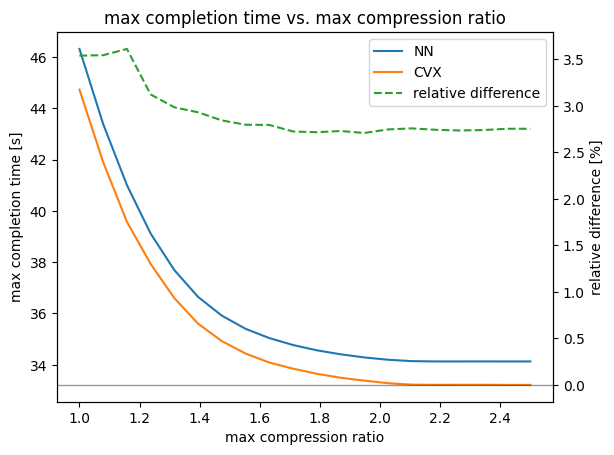

In [29]:
t_total_nn = np.array([p.get_t_total_max() for p in prob_beta])
t_total_cvx = t_total_beta_cvx
relative_diff_pct = 100 * (t_total_nn - t_total_cvx) / np.maximum(np.abs(t_total_cvx), 1e-12)

fig, ax1 = plt.subplots()
ax1.plot(beta, t_total_nn, label='NN', color='tab:blue')
ax1.plot(beta, t_total_cvx, label='CVX', color='tab:orange')
ax1.set_xlabel('max compression ratio')
ax1.set_ylabel('max completion time [s]')

ax2 = ax1.twinx()
ax2.plot(beta, relative_diff_pct, label='relative difference', color='tab:green', linestyle='--')
ax2.axhline(0, color='black', linewidth=1, alpha=0.4, label='_nolegend_')
ax2.set_ylabel('relative difference [%]')

lines = ax1.get_lines() + ax2.get_lines()
lines = [line for line in lines if not line.get_label().startswith('_')]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels)
plt.title('max completion time vs. max compression ratio')


varied p_k

In [30]:
prob_p_k = []

for i in range(len(tr_power)):
    print(f'i = {i}')
    p_k = np.ones((test_length, K)) * tr_power[i]
    prob_p_k.append(Problem(D, H, tr_power=p_k))
    prob_p_k[-1].optimize(model=train_cached_model(prob_p_k[-1], print_losses=False))

t_total_p_k_cvx = get_cached_cvx_curve(
    'transmit_power',
    tr_power,
    lambda p_value: Problem(D, H, tr_power=np.ones((test_length, K)) * p_value),
)


i = 0
start training
best epoch: 01, best avg loss: 1002.082825
i = 1
start training
best epoch: 01, best avg loss: 500.963898
i = 2
start training
best epoch: 01, best avg loss: 436.531586
i = 3
start training
best epoch: 01, best avg loss: 412.645874
i = 4
start training
best epoch: 01, best avg loss: 400.440491
i = 5
start training
best epoch: 01, best avg loss: 393.131744
i = 6
start training
best epoch: 01, best avg loss: 388.268677
i = 7
start training
best epoch: 01, best avg loss: 384.836151
i = 8
start training
best epoch: 01, best avg loss: 382.243591
i = 9
start training
best epoch: 01, best avg loss: 380.223999
i = 10
start training
best epoch: 01, best avg loss: 378.621674
i = 11
start training
best epoch: 01, best avg loss: 377.302399


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:376: RuntimeWarning: divide by zero encountered in divide
  1 / (mu) - beta,
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:238: RuntimeWarning: invalid value encountered in add
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


i = 12
start training
best epoch: 01, best avg loss: 376.217010
i = 13
start training
best epoch: 01, best avg loss: 375.296082
i = 14
start training
best epoch: 01, best avg loss: 374.513336
i = 15
start training
best epoch: 01, best avg loss: 373.838837
i = 16
start training
best epoch: 01, best avg loss: 373.250580
i = 17
start training
best epoch: 01, best avg loss: 372.737488
i = 18
start training
best epoch: 01, best avg loss: 372.304565
i = 19
start training
best epoch: 01, best avg loss: 371.902161
running CVX result: transmit_power
cvx transmit_power i = 0
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scenario(s): [30]
MOSEK skipped 1 scen

Text(0.5, 1.0, 'max completion time vs. transmit power')

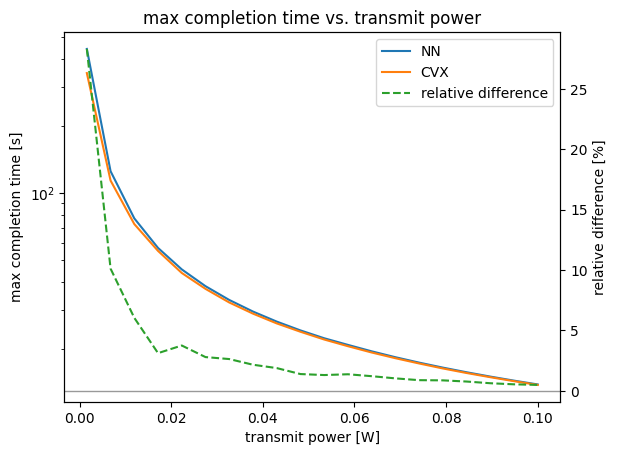

In [31]:
t_total_nn = np.array([p.get_t_total_max() for p in prob_p_k])
t_total_cvx = t_total_p_k_cvx
relative_diff_pct = 100 * (t_total_nn - t_total_cvx) / np.maximum(np.abs(t_total_cvx), 1e-12)

fig, ax1 = plt.subplots()
ax1.semilogy(tr_power, t_total_nn, label='NN', color='tab:blue')
ax1.semilogy(tr_power, t_total_cvx, label='CVX', color='tab:orange')
ax1.set_xlabel('transmit power [W]')
ax1.set_ylabel('max completion time [s]')

ax2 = ax1.twinx()
ax2.plot(tr_power, relative_diff_pct, label='relative difference', color='tab:green', linestyle='--')
ax2.axhline(0, color='black', linewidth=1, alpha=0.4, label='_nolegend_')
ax2.set_ylabel('relative difference [%]')

lines = ax1.get_lines() + ax2.get_lines()
lines = [line for line in lines if not line.get_label().startswith('_')]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels)
plt.title('max completion time vs. transmit power')


varied B

In [36]:
prob_B = []

for i in range(len(B_total)):
    print(f'i = {i}')
    prob_B.append(Problem(D, H, total_bandwidth=B_total[i]))
    prob_B[-1].optimize(model=train_cached_model(prob_B[-1], print_losses=False))

t_total_B_cvx = get_cached_cvx_curve(
    'bandwidth',
    B_total,
    lambda bandwidth: Problem(D, H, total_bandwidth=bandwidth),
)


i = 0
loading cached model: model\checkpoint_K_4_B_100_beta_3_p_0.0316_29066c33c0.pth


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:202: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:236: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:238: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


i = 1
loading cached model: model\checkpoint_K_4_B_144_beta_3_p_0.0316_6ffa214de4.pth
i = 2
loading cached model: model\checkpoint_K_4_B_207_beta_3_p_0.0316_abce2ed05b.pth
i = 3
loading cached model: model\checkpoint_K_4_B_298_beta_3_p_0.0316_99e8c97b7d.pth
i = 4
loading cached model: model\checkpoint_K_4_B_428_beta_3_p_0.0316_5e81a64ddb.pth
i = 5
loading cached model: model\checkpoint_K_4_B_616_beta_3_p_0.0316_abc4ba4c6c.pth
i = 6
loading cached model: model\checkpoint_K_4_B_886_beta_3_p_0.0316_4c50320d2c.pth
i = 7
loading cached model: model\checkpoint_K_4_B_1.27e+03_beta_3_p_0.0316_531eb014df.pth
i = 8
loading cached model: model\checkpoint_K_4_B_1.83e+03_beta_3_p_0.0316_d5abf0c7ee.pth
i = 9
loading cached model: model\checkpoint_K_4_B_2.64e+03_beta_3_p_0.0316_a98d40b581.pth
i = 10
loading cached model: model\checkpoint_K_4_B_3.79e+03_beta_3_p_0.0316_94044c50b4.pth
i = 11
loading cached model: model\checkpoint_K_4_B_5.46e+03_beta_3_p_0.0316_d5755dfd00.pth
i = 12
loading cached model

Text(0.5, 1.0, 'max completion time vs. total bandwidth')

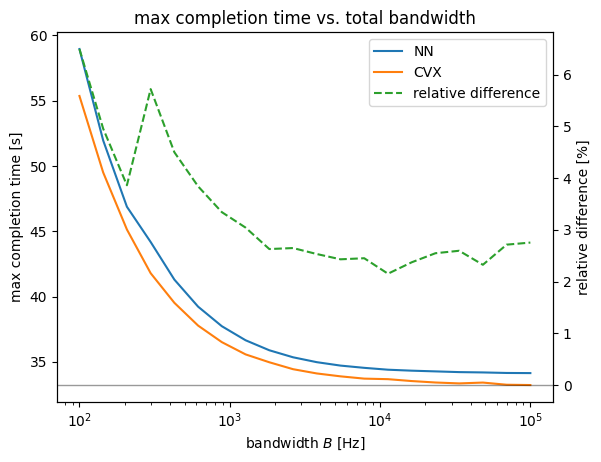

In [37]:
t_total_nn = np.array([p.get_t_total_max() for p in prob_B])
t_total_cvx = t_total_B_cvx
relative_diff_pct = 100 * (t_total_nn - t_total_cvx) / np.maximum(np.abs(t_total_cvx), 1e-12)

fig, ax1 = plt.subplots()
ax1.semilogx(B_total, t_total_nn, label='NN', color='tab:blue')
ax1.semilogx(B_total, t_total_cvx, label='CVX', color='tab:orange')
ax1.set_xlabel('bandwidth $B$ [Hz]')
ax1.set_ylabel('max completion time [s]')

ax2 = ax1.twinx()
ax2.semilogx(B_total, relative_diff_pct, label='relative difference', color='tab:green', linestyle='--')
ax2.axhline(0, color='black', linewidth=1, alpha=0.4, label='_nolegend_')
ax2.set_ylabel('relative difference [%]')

lines = ax1.get_lines() + ax2.get_lines()
lines = [line for line in lines if not line.get_label().startswith('_')]
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels)
plt.title('max completion time vs. total bandwidth')


relative differences between NN and CVX for random scenarios

scenario 0: beta=1.703, p=0.02713, B=136.6
start training
best epoch: 01, best avg loss: 97.487122
scenario 1: beta=1.722, p=0.096, B=9069
start training
best epoch: 01, best avg loss: 25.270058
scenario 2: beta=1.743, p=0.01249, B=571.9
start training
best epoch: 01, best avg loss: 146.153687
scenario 3: beta=1.442, p=0.07686, B=4.267e+04
start training
best epoch: 01, best avg loss: 28.088995
scenario 4: beta=2.352, p=0.09848, B=8.853e+04
start training
best epoch: 01, best avg loss: 60.396118
scenario 5: beta=2.429, p=0.008667, B=259
start training
best epoch: 17, best avg loss: 217.985077
scenario 6: beta=1.457, p=0.05601, B=195.4
start training
best epoch: 01, best avg loss: 58.852520
scenario 7: beta=2.269, p=0.06229, B=4237
start training
best epoch: 01, best avg loss: 58.179832
scenario 8: beta=1.248, p=0.02652, B=302.6
start training
best epoch: 01, best avg loss: 92.604919
scenario 9: beta=2.278, p=0.05909, B=1.605e+04
start training
best epoch: 01, best avg loss: 59.375587
s

,scenario,K,beta_max,transmit_power_W,bandwidth_Hz,t_total_NN_s,t_total_CVX_s,relative_diff_pct,abs_relative_diff_pct
0,0,4,1.702625,0.027129,136.621595,34.366463,34.315811,0.147604,0.147604
1,1,4,1.722237,0.095998,9068.962420,7.642759,7.527770,1.527534,1.527534
2,2,4,1.743260,0.012492,571.885219,34.579731,34.347878,0.675015,0.675015
3,3,4,1.442161,0.076857,42670.957856,8.155037,8.117130,0.466996,0.466996
4,4,4,2.352463,0.098482,88531.953922,7.030330,7.002489,0.397588,0.397588
...,...,...,...,...,...,...,...,...,...
95,95,4,2.234661,0.040813,93576.192882,12.289818,12.281703,0.066072,0.066072
96,96,4,1.205817,0.065908,2219.159519,10.767933,10.544593,2.118053,2.118053
97,97,4,1.589377,0.087708,84486.425765,7.495764,7.469749,0.348262,0.348262
98,98,4,2.309288,0.020522,459.614545,26.171747,26.050358,0.465980,0.465980


mean relative diff: 1.40%
mean absolute relative diff: 1.40%


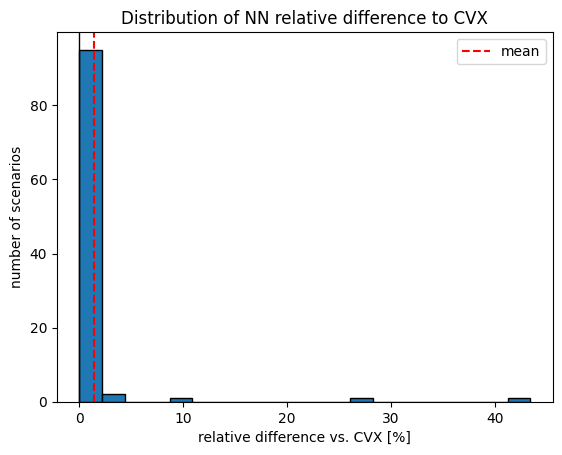

In [34]:
n_random_scenarios = 100
random_K = 4
samples_per_scenario = 1
# rng = np.random.default_rng(42)

relative_diff_rows = []

for i in range(n_random_scenarios):
    total_data_bits = random_K * 4e3
    D_random = (DataUtil.generate_D_k_distribution(samples_per_scenario, random_K) * total_data_bits).numpy()
    H_random = DataUtil.generate_channel_gains(samples_per_scenario, random_K).numpy()

    beta_max_random = rng.uniform(1.0, 2.5)
    tr_power_random = rng.uniform(1.6e-3, 100e-3)
    bandwidth_random = 10 ** rng.uniform(2, 5)
    p_random = np.ones((samples_per_scenario, random_K)) * tr_power_random

    print(f'scenario {i}: beta={beta_max_random:.3f}, p={tr_power_random:.4g}, B={bandwidth_random:.4g}')

    prob_nn = Problem(
        D_random,
        H_random,
        tr_power=p_random,
        beta_max=beta_max_random,
        total_bandwidth=bandwidth_random,
    )
    prob_nn.optimize(model=train_cached_model(prob_nn, print_losses=False))
    t_nn = prob_nn.get_t_total_max()

    prob_cvx = Problem(
        D_random,
        H_random,
        tr_power=p_random,
        beta_max=beta_max_random,
        total_bandwidth=bandwidth_random,
    )
    prob_cvx.optimize(model='cvx')
    t_cvx = prob_cvx.get_t_total_max()

    relative_diff_pct = 100 * (t_nn - t_cvx) / max(abs(t_cvx), 1e-12)

    relative_diff_rows.append(
        {
            'scenario': i,
            'K': random_K,
            'beta_max': beta_max_random,
            'transmit_power_W': tr_power_random,
            'bandwidth_Hz': bandwidth_random,
            't_total_NN_s': t_nn,
            't_total_CVX_s': t_cvx,
            'relative_diff_pct': relative_diff_pct,
            'abs_relative_diff_pct': abs(relative_diff_pct),
        }
    )

relative_diff_df = pd.DataFrame(relative_diff_rows)
display(relative_diff_df)

print(f"mean relative diff: {relative_diff_df['relative_diff_pct'].mean():.2f}%")
print(f"mean absolute relative diff: {relative_diff_df['abs_relative_diff_pct'].mean():.2f}%")

plt.figure()
plt.hist(relative_diff_df['relative_diff_pct'], bins='auto', edgecolor='black')
plt.axvline(0, color='black', linewidth=1)
plt.axvline(relative_diff_df['relative_diff_pct'].mean(), color='red', linestyle='--', label='mean')
plt.xlabel('relative difference vs. CVX [%]')
plt.ylabel('number of scenarios')
plt.title('Distribution of NN relative difference to CVX')
plt.legend()


covariance between scenario parameters and relative difference

In [14]:
covariance_columns = [
    'beta_max',
    'transmit_power_W',
    'bandwidth_Hz',
    'relative_diff_pct',
]

corr_df = relative_diff_df[covariance_columns].corr()
corr_to_diff = corr_df[['relative_diff_pct']].drop(index='relative_diff_pct')

display(corr_to_diff.rename(columns={'relative_diff_pct': 'correlation_with_relative_diff_pct'}))


,correlation_with_relative_diff_pct
beta_max,-0.017475
transmit_power_W,0.050802
bandwidth_Hz,-0.212321


Runtime

In [ ]:


set_seed()

Ks = np.arange(10, 100, 10)
# Ks = np.arange(4, 10, 2)
test_length = 100

# Ds = []
# Hs = []

# for k in Ks:
#     total_data_bits = k * 4e3
#     D = DataUtil.generate_D_k_distribution(test_length, k) * total_data_bits
#     Ds += [D.numpy()]
#     H = DataUtil.generate_channel_gains(test_length, k)
#     Hs += [H.numpy()]
    
# with open("data/D.pkl", "wb") as f:
#     pickle.dump(Ds, f)
    
# with open("data/H.pkl", "wb") as f:
#     pickle.dump(Hs, f)

In [ ]:
with open("data/D.pkl", "rb") as f:
    Ds = pickle.load(f)
    
with open("data/H.pkl", "rb") as f:
    Hs = pickle.load(f)

In [ ]:

total_time_used_NN = []
leader_time_used_NN = []
result_dfs = []
prob = []

for i in range(len(Ks)):
    k = Ks[i]
    # print(f'K = {k} \n---------------')
    prob += [Problem(Ds[i], Hs[i])]
    model = train_cached_model(prob[-1], print_losses=False)
    prob[-1].optimize(model=model)
    result_dfs.append(prob[-1].to_df())
    total_time_used_NN.append(prob[-1].get_total_time_used())
    leader_time_used_NN.append(np.mean(prob[-1].get_leader_time_used()))

In [159]:
total_time_used_cvx = []
leader_time_used_cvx = []
result_dfs = []
prob = []

for i in range(len(Ks)):
    k = Ks[i]
    print(k)
    prob += [Problem(Ds[i], Hs[i], None, None)]
    prob[-1].optimize(model='cvx')
    result_dfs.append(prob[-1].to_df())
    total_time_used_cvx.append(prob[-1].get_total_time_used())
    leader_time_used_cvx.append(np.mean(prob[-1].get_leader_time_used()))

10


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:243: RuntimeWarning: divide by zero encountered in log
  beta_values = (1 / epsilon) * np.log(
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:280: RuntimeWarning: divide by zero encountered in divide
  g2 = 1 / (mu) - beta
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:282: RuntimeWarning: invalid value encountered in multiply
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


20
30


c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:387: RuntimeWarning: divide by zero encountered in divide
  1 / (mu) - beta,
c:\Users\YCMic\Documents\Bachelor-Thesis\src\Problem.py:282: RuntimeWarning: invalid value encountered in add
  return objective + lam[:, :, 0] * g1 + lam[:, :, 1] * g2


40
50
60
70
MOSEK skipped 1 scenario(s).
80
MOSEK skipped 1 scenario(s).
MOSEK skipped 1 scenario(s).
90
MOSEK skipped 1 scenario(s).


np.float32(172.0955)

Text(0.5, 1.0, 'time used performing optimization')

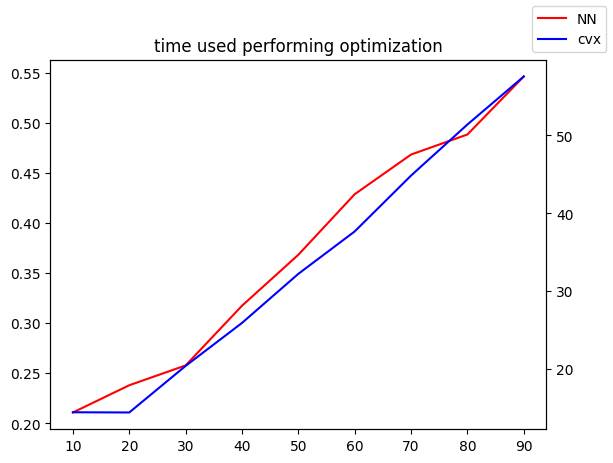

In [ ]:


fig, ax1 = plt.subplots()


ax1.plot(Ks, total_time_used_NN, c='r', label='NN')

ax2 = ax1.twinx()
ax2.plot(Ks, total_time_used_cvx, c='b', label='cvx')
fig.legend()
plt.title('time used performing optimization')

|   sensor_num |        D |   H(dB) |         b |         f |   beta |   comp_speed |   tr_power |   $t_{total}$ |   $t_{comp}$ |   $t_{tr}$ |   $t_{dt}$ |
|-------------:|---------:|--------:|----------:|----------:|-------:|-------------:|-----------:|--------------:|-------------:|-----------:|-----------:|
|            0 | 2.17e+03 |  -40.65 | 1.255e+04 | 6.678e+06 |   1.34 |     2.00e+05 |   3.16e-02 |         64.30 |         2.68 |      21.06 |      40.57 |
|            1 | 9.02e+03 |  -41.00 | 1.290e+04 | 7.992e+06 |   1.37 |     2.00e+05 |   3.16e-02 |         64.29 |         2.13 |      14.27 |      47.89 |
|            2 | 8.47e+03 |  -40.56 | 1.262e+04 | 5.041e+06 |   1.32 |     2.00e+05 |   3.16e-02 |         64.29 |         1.72 |      11.69 |      50.88 |
|            3 | 2.18e+03 |  -40.96 | 1.216e+04 | 5.596e+06 |   1.36 |     2.00e+05 |   3.16e-02 |         64.29 |         1.87 |      12.57 |      49.85 |
|            4 | 8.34e+02 |  -40.79 | 1.253e+04 | 7.021e+06 |   1.36 |     2.00e+05 |   3.16e-02 |         64.29 |         2.84 |      19.81 |      41.65 |
|            5 | 3.22e+03 |  -40.89 | 1.224e+04 | 5.522e+06 |   1.36 |     2.00e+05 |   3.16e-02 |         64.29 |         2.12 |      14.75 |      47.41 |
|            6 | 2.59e+03 |  -40.70 | 1.238e+04 | 5.485e+06 |   1.34 |     2.00e+05 |   3.16e-02 |         64.29 |         1.95 |      13.18 |      49.17 |
|            7 | 3.50e+03 |  -40.64 | 1.264e+04 | 6.665e+06 |   1.33 |     2.00e+05 |   3.16e-02 |         64.29 |         1.75 |      11.88 |      50.66 |

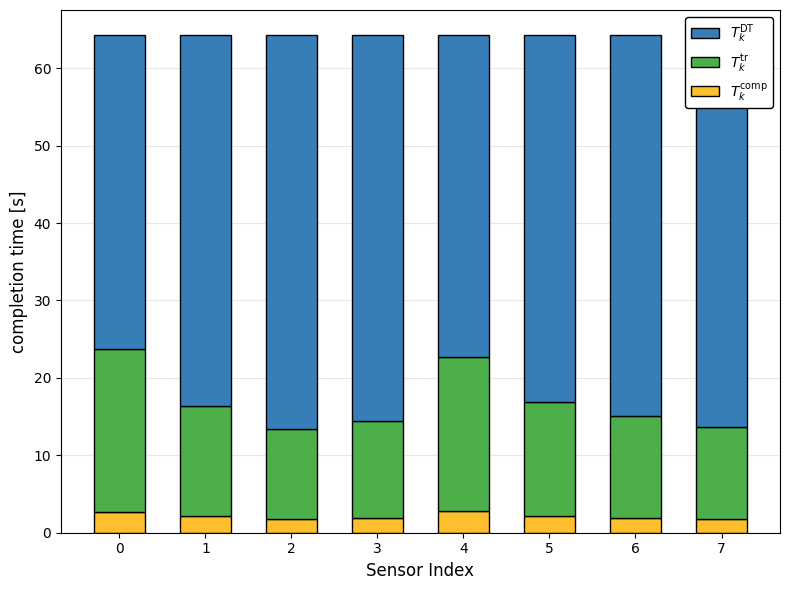

In [134]:



K = 8


total_data_bits = K * 4e3

D = DataUtil.generate_D_k_distribution(test_length, K) * total_data_bits
D = D.numpy()
H = DataUtil.generate_channel_gains(test_length, K)
H = H.numpy()
problem = Problem(D, H, None, None)
model = train_cached_model(problem, print_losses=False)
problem.optimize(model)
problem.plot()
problem.print_avg()